# StructML (236605) Assignment 2 - Node and Tuple Embedding

Database: `rel-stack` (relbench). Task: `user-engagement` (predict for each user if they will make any votes, posts or comments in the next 3 months).

We reuse the feature matrices from assignment 1 (saved in `../features/`) and train 4 base embeddings with dimension k=128: kernel PCA (tuple embedding), Laplacian eigenmaps, Node2Vec and Metapath2Vec (node embeddings).

Heavy results are cached in `./artifacts`. Delete a file there to recompute it from scratch.

Extra install used here: `pip install pyg-lib -f https://data.pyg.org/whl/torch-2.11.0+cu130.html` (fast random walk backend for PyG).

In [2]:
# ---------- Setup ----------
import os, sys, json, time, gc, ctypes
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# pyg-lib (used by PyG for random walks) needs libnvrtc.so.13 from the conda
# env lib dir, which is not on the loader search path under WSL. Preload it.
_nvrtc = os.path.join(sys.prefix, "lib", "libnvrtc.so.13")
if os.path.exists(_nvrtc):
    ctypes.CDLL(_nvrtc, mode=ctypes.RTLD_GLOBAL)

K = 128                # embedding dimension for the whole assignment
SEED = 0
ART = "artifacts"      # cache directory for heavy results
FEAT = "../features"   # feature matrices from assignment 1
os.makedirs(ART, exist_ok=True)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


## Part 1: Train Base Embeddings

### Q1 - Tuple embedding via dimensionality reduction (kernel PCA)

Steps: remove the label column (`contribution`), remove textual attributes, transform every timestamp attribute into "days before the target timestamp", impute missing values with `SimpleImputer(strategy='median')`, and remove attributes where all values are missing. Then approximate kernel PCA: `Nystroem` projects the rows into an approximate RBF kernel space, and `PCA` reduces that space to k=128. Everything is fit on the train rows, the val rows are only transformed.

In [3]:
# ---------- Q1: numeric matrix from the hw1 feature matrix ----------
fm_train = pd.read_pickle(f"{FEAT}/fm_train_graph.pkl")
fm_val   = pd.read_pickle(f"{FEAT}/fm_val_graph.pkl")

# row-aligned task info, used all over the assignment
uid_train = fm_train["OwnerUserId"].to_numpy(np.int64)
y_train   = fm_train["contribution"].to_numpy(np.int64)
uid_val   = fm_val["OwnerUserId"].to_numpy(np.int64)
y_val     = fm_val["contribution"].to_numpy(np.int64)

def numeric_feature_matrix(fm, ref_cols=None):
    """Label removed, textual columns removed, timestamps -> days before the
    target timestamp, key/timestamp columns removed."""
    out = {}
    ts = fm["timestamp"]
    for c in fm.columns:
        if c in ("contribution", "OwnerUserId", "timestamp") or fm[c].dtype == object:
            continue
        if pd.api.types.is_datetime64_any_dtype(fm[c]):
            out["DaysSince__" + c] = ((ts - fm[c]).dt.total_seconds() / 86400.0).to_numpy(np.float32)
        else:
            out[c] = fm[c].to_numpy(np.float32)
    out = pd.DataFrame(out, copy=False)
    return out[ref_cols] if ref_cols is not None else out

Xn_train = numeric_feature_matrix(fm_train)
Xn_val   = numeric_feature_matrix(fm_val, ref_cols=list(Xn_train.columns))
del fm_train, fm_val; gc.collect()
print("numeric matrices:", Xn_train.shape, Xn_val.shape)
Xn_train.head(3)

numeric matrices: (1360850, 53) (85838, 53)


,users__Id,users__ProfileImageUrl,DaysSince__users__CreationDate,users__DisplayName__count,users__Location__count,users__ProfileImageUrl__mean,users__ProfileImageUrl__count,users__ProfileImageUrl__sum,users__WebsiteUrl__count,users__AboutMe__count,...,comments__UserDisplayName__count,comments__Text__count,DaysSince__comments__CreationDate__min,DaysSince__comments__CreationDate__max,graph_degree,wl_K2,wl_K3,wl_K5,self_comment_count,linked_own_posts_count
0,352.0,NaN,533.492676,1.0,1.0,NaN,0.0,NaN,1.0,1.0,...,0.0,353.0,509.470703,2.231586,1564.0,242.0,248.0,248.0,75.0,0.0
1,7.0,NaN,86.204948,1.0,1.0,NaN,0.0,NaN,1.0,1.0,...,0.0,72.0,86.169228,0.621124,949.0,7.0,7.0,7.0,57.0,1.0
2,1693.0,NaN,8.261730,1.0,1.0,NaN,0.0,NaN,1.0,1.0,...,0.0,1.0,6.150768,6.150768,2578.0,992.0,1035.0,1035.0,112.0,0.0


In [4]:
# ---------- Q1: approximate kernel PCA (Nystroem RBF -> PCA) ----------
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.kernel_approximation import Nystroem
from sklearn.decomposition import PCA

def kernel_pca_embeddings(n_kernel_features=256):
    global Xn_train, Xn_val
    # median imputation; drop attributes where all train values are missing
    imp0 = SimpleImputer(strategy="median").fit(Xn_train)
    keep = list(Xn_train.columns[~np.isnan(imp0.statistics_)])
    dropped = [c for c in Xn_train.columns if c not in set(keep)]
    print("all-missing columns dropped:", dropped)
    imp = SimpleImputer(strategy="median").fit(Xn_train[keep])
    X_tr = imp.transform(Xn_train[keep]).astype(np.float32)
    X_va = imp.transform(Xn_val[keep]).astype(np.float32)

    # the RBF kernel is distance based, so the features need comparable scales
    scaler = StandardScaler().fit(X_tr)
    X_tr = scaler.transform(X_tr)
    X_va = scaler.transform(X_va)

    # Nystroem learns an explicit feature map into an approximate RBF kernel
    # space, so the full n x n kernel matrix is never built
    rng = np.random.RandomState(SEED)
    sub = rng.choice(len(X_tr), 100_000, replace=False)
    nys = Nystroem(kernel="rbf", n_components=n_kernel_features, random_state=SEED).fit(X_tr[sub])

    def nys_chunks(X, chunk=200_000):
        return np.vstack([nys.transform(X[i:i + chunk]).astype(np.float32)
                          for i in range(0, len(X), chunk)])
    F_tr, F_va = nys_chunks(X_tr), nys_chunks(X_va)

    pca = PCA(n_components=K, random_state=SEED).fit(F_tr)
    return pca.transform(F_tr).astype(np.float32), pca.transform(F_va).astype(np.float32)

if os.path.exists(f"{ART}/kpca_train.npy"):
    kpca_train = np.load(f"{ART}/kpca_train.npy")
    kpca_val   = np.load(f"{ART}/kpca_val.npy")
else:
    t0 = time.time()
    kpca_train, kpca_val = kernel_pca_embeddings()
    np.save(f"{ART}/kpca_train.npy", kpca_train)
    np.save(f"{ART}/kpca_val.npy", kpca_val)
    print(f"done in {time.time() - t0:.0f}s")
del Xn_train, Xn_val; gc.collect()
print("kernel PCA embeddings:", kpca_train.shape, kpca_val.shape)

kernel PCA embeddings: (1360850, 128) (85838, 128)


### Q2 - Database graph

We keep all tuples with timestamp up to and including `dataset.val_timestamp` (2020-10-01), drop all attributes except PKs and FKs, build the heterograph with relbench's `make_pkey_fkey_graph`, and convert it to a homogeneous graph with `to_homogeneous()`. relbench stores every PK-FK edge in both directions, so the graph is undirected in practice.

In [5]:
# ---------- Q2: PK-FK graph over all tuples up to val_timestamp ----------
GRAPH_PATH = f"{ART}/graph.pt"

def build_graph():
    from relbench.datasets import get_dataset
    from relbench.modeling.graph import make_pkey_fkey_graph

    dataset = get_dataset("rel-stack", download=True)
    db = dataset.get_db().upto(dataset.val_timestamp)
    # the cached db is time-sorted with arange pkeys, so the rows up to
    # val_timestamp are a prefix of each table and reindexing keeps every
    # surviving row's index unchanged. This is what lets us map task user ids
    # directly to node indices. The assert verifies it.
    for name, tbl in db.table_dict.items():
        assert (tbl.df[tbl.pkey_col].to_numpy() == np.arange(len(tbl.df))).all(), name
    db.reindex_pkeys_and_fkeys()

    # empty stype dict per table = keep nothing except PKs and FKs
    # (relbench inserts a constant placeholder feature per node)
    data, _ = make_pkey_fkey_graph(db, {name: {} for name in db.table_dict})

    edge_index_dict = {et: data[et].edge_index for et in data.edge_types}
    num_nodes_dict = {}
    for nt in data.node_types:
        num_nodes_dict[nt] = data[nt].tf.num_rows
        data[nt].num_nodes = data[nt].tf.num_rows
        del data[nt].tf  # placeholder features are not needed
    offsets, off = {}, 0
    for nt in data.node_types:
        offsets[nt] = off
        off += num_nodes_dict[nt]
    homo = data.to_homogeneous(node_attrs=["time"])
    deg = torch.bincount(homo.edge_index[0], minlength=homo.num_nodes)

    # per-user activity counts, used for the Q4 colorings
    n_users = num_nodes_dict["users"]
    user_n_posts = np.zeros(n_users, np.int64)
    vc = db.table_dict["posts"].df["OwnerUserId"].value_counts()
    user_n_posts[vc.index.to_numpy(np.int64)] = vc.to_numpy()
    user_n_badges = np.zeros(n_users, np.int64)
    vc = db.table_dict["badges"].df["UserId"].value_counts()
    user_n_badges[vc.index.to_numpy(np.int64)] = vc.to_numpy()

    return {"edge_index": homo.edge_index, "node_type": homo.node_type,
            "node_types": list(data.node_types), "num_nodes": homo.num_nodes,
            "num_nodes_dict": num_nodes_dict, "edge_index_dict": edge_index_dict,
            "offsets": offsets, "deg": deg,
            "user_n_posts": user_n_posts, "user_n_badges": user_n_badges}

if os.path.exists(GRAPH_PATH):
    G = torch.load(GRAPH_PATH, weights_only=False)
else:
    G = build_graph()
    torch.save(G, GRAPH_PATH)

OFF_USERS = G["offsets"]["users"]
N_USERS = G["num_nodes_dict"]["users"]
deg_arr = G["deg"].numpy()
user_n_posts, user_n_badges = G["user_n_posts"], G["user_n_badges"]

# data quirk of rel-stack: a handful of task users have a CreationDate after
# val_timestamp, so they have no node in the graph (they get zero embeddings)
print("task rows whose user is not in the graph:",
      f"train={int((uid_train >= N_USERS).sum())}, val={int((uid_val >= N_USERS).sum())}")

def user_rows(emb, uids, offset=0):
    """Embedding rows for an array of user ids. Users without a node in the
    graph get a zero vector."""
    out = np.zeros((len(uids), emb.shape[1]), dtype=np.float32)
    m = uids < N_USERS
    out[m] = emb[offset + uids[m]]
    return out

print("a. number of nodes:", G["num_nodes"])
print("b. number of edges:", G["edge_index"].shape[1] // 2,
      f"undirected ({G['edge_index'].shape[1]} directed, each edge stored in both directions)")
print(f"c. node degree: min={deg_arr.min()}  max={deg_arr.max()}  "
      f"avg={deg_arr.mean():.3f}  median={np.median(deg_arr):.1f}")
print("\nnodes per table:", G["num_nodes_dict"])

task rows whose user is not in the graph: train=107, val=13
a. number of nodes: 4121747
b. number of edges: 5642180 undirected (11284360 directed, each edge stored in both directions)
c. node degree: min=0  max=68018  avg=2.738  median=2.0

nodes per table: {'users': 247398, 'postHistory': 1141610, 'postLinks': 74435, 'votes': 1278841, 'posts': 324981, 'badges': 448358, 'comments': 606124}


**Q2 answer:**
- a. Number of nodes: 4,121,747
- b. Number of edges: 5,642,180 undirected edges (stored as 11,284,360 directed edges, one per direction)
- c. Node degree: min = 0, max = 68,018, average = 2.74, median = 2.0

Nodes per table: users 247,398; postHistory 1,141,610; postLinks 74,435; votes 1,278,841; posts 324,981; badges 448,358; comments 606,124.

Note: 107 train rows (11 distinct users) and 13 val rows belong to users whose account CreationDate in rel-stack is after val_timestamp (a quirk of the data), so they have no node in this graph. Wherever node embeddings are used for the task rows, these few users get a zero vector.

### Q3a - Laplacian eigenmaps

sklearn's spectral embedding cannot handle a 4.1M x 4.1M matrix, so we use `randomized_svd` on a sparse `csr_matrix`. We factorize the symmetrically normalized adjacency D^-1/2 A D^-1/2: its top singular vectors are (up to sign) the eigenvectors with the smallest eigenvalues of the normalized Laplacian L = I - D^-1/2 A D^-1/2, which is exactly what Laplacian eigenmaps computes.

In [6]:
# ---------- Q3a: Laplacian eigenmaps via randomized SVD ----------
import scipy.sparse as sp
from sklearn.utils.extmath import randomized_svd

def laplacian_eigenmaps():
    n = G["num_nodes"]
    r, c = G["edge_index"].numpy()
    # both directions of every PK-FK edge are stored -> A is symmetric (undirected)
    A = sp.csr_matrix((np.ones(len(r), np.float32), (r, c)), shape=(n, n))
    A.sum_duplicates()
    A.data[:] = 1.0  # binary adjacency
    d = np.asarray(A.sum(axis=1)).ravel()
    Dm12 = sp.diags((1.0 / np.sqrt(np.maximum(d, 1.0))).astype(np.float32))
    A_norm = (Dm12 @ A @ Dm12).tocsr()
    U, S, _ = randomized_svd(A_norm, n_components=K, random_state=SEED)
    return U.astype(np.float32)

if os.path.exists(f"{ART}/lap_emb.npy"):
    lap_emb = np.load(f"{ART}/lap_emb.npy")
else:
    t0 = time.time()
    lap_emb = laplacian_eigenmaps()
    np.save(f"{ART}/lap_emb.npy", lap_emb)
    print(f"done in {time.time() - t0:.0f}s")
gc.collect()
print("laplacian eigenmaps:", lap_emb.shape)

laplacian eigenmaps: (4121747, 128)


### Q3b - Node2Vec

PyG implementation, walk length 24, context size 5, Adam with learning rate 0.01, batch size 128 with shuffled data loading, 25 epochs. The embedding table produces sparse gradients (only rows that appear in a batch), so we use `torch.optim.SparseAdam`, the Adam variant for sparse gradients (this is also what the official PyG Node2Vec example uses; dense Adam would update all 4.1M rows every step). With ~4.1M nodes there are ~32,200 batches per epoch, so the 25 epochs take a few hours on a laptop GPU. If the GPU runs out of memory, lower the batch size (per the assignment note) or set `device = "cpu"`.

/home/abed/miniconda3/envs/structml1/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


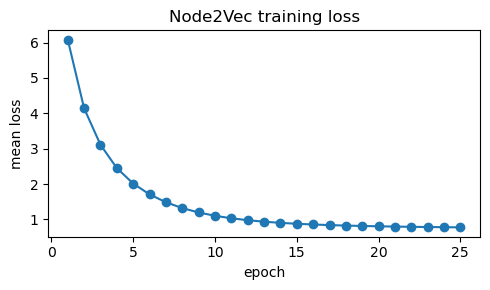

node2vec embeddings: (4121747, 128)


In [7]:
# ---------- Q3b: Node2Vec ----------
from torch_geometric.nn.models import Node2Vec

def train_node2vec(epochs=25, batch_size=128, lr=0.01):
    torch.manual_seed(SEED)
    model = Node2Vec(G["edge_index"], embedding_dim=K, walk_length=24,
                     context_size=5, walks_per_node=1, p=1.0, q=1.0,
                     num_negative_samples=1, num_nodes=G["num_nodes"],
                     sparse=True).to(device)
    loader = model.loader(batch_size=batch_size, shuffle=True,
                          num_workers=6, persistent_workers=True)
    opt = torch.optim.SparseAdam(list(model.parameters()), lr=lr)
    losses = []
    for epoch in range(1, epochs + 1):
        model.train()
        tot, nb, t0 = 0.0, 0, time.time()
        for pos_rw, neg_rw in loader:
            opt.zero_grad()
            loss = model.loss(pos_rw.to(device), neg_rw.to(device))
            loss.backward()
            opt.step()
            tot += loss.item()
            nb += 1
        losses.append(tot / nb)
        print(f"epoch {epoch:2d}/{epochs}  loss={losses[-1]:.4f}  ({time.time() - t0:.0f}s)", flush=True)
    emb = model.embedding.weight.detach().cpu().numpy().astype(np.float32)
    del model, loader, opt
    return emb, losses

if os.path.exists(f"{ART}/n2v_emb.npy"):
    n2v_emb = np.load(f"{ART}/n2v_emb.npy")
    n2v_losses = json.load(open(f"{ART}/n2v_losses.json"))
else:
    n2v_emb, n2v_losses = train_node2vec()
    np.save(f"{ART}/n2v_emb.npy", n2v_emb)
    json.dump(n2v_losses, open(f"{ART}/n2v_losses.json", "w"))
    gc.collect(); torch.cuda.empty_cache()

plt.figure(figsize=(5, 3))
plt.plot(range(1, len(n2v_losses) + 1), n2v_losses, marker="o")
plt.xlabel("epoch"); plt.ylabel("mean loss"); plt.title("Node2Vec training loss")
plt.tight_layout(); plt.show()
print("node2vec embeddings:", n2v_emb.shape)

### Q3c - Metapath2Vec

Same parameters as Node2Vec, metapath user-post-comment-user, trained on the heterograph (before the homogeneous conversion). The heterograph stores every PK-FK edge in both directions, and we use this undirected version to define the metapath relations so walkers do not get stuck:
- user -> post: the reversed `posts.OwnerUserId` edge,
- post -> comment: the reversed `comments.PostId` edge,
- comment -> user: the `comments.UserId` edge.

The metapath is cyclic (it ends at the type it starts from), so PyG repeats it 8 times along the 24-step walk. Walks that still hit a dead end (for example a post with no comments) are routed by PyG to a dummy node that is excluded from the output. Only users, posts and comments get embeddings from this method.

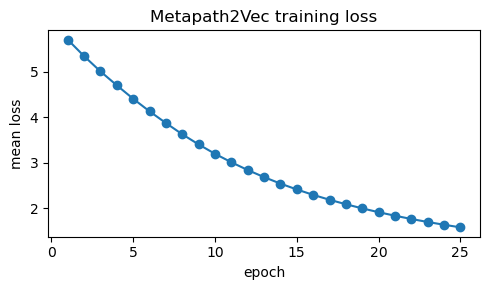

metapath2vec embeddings: {'users': (247398, 128), 'posts': (324981, 128), 'comments': (606124, 128)}


In [8]:
# ---------- Q3c: Metapath2Vec ----------
from torch_geometric.nn.models import MetaPath2Vec

METAPATH = [("users", "rev_f2p_OwnerUserId", "posts"),     # user -> their posts
            ("posts", "rev_f2p_PostId", "comments"),       # post -> its comments
            ("comments", "f2p_UserId", "users")]           # comment -> its author

def train_metapath2vec(epochs=25, batch_size=128, lr=0.01):
    torch.manual_seed(SEED)
    edge_index_dict = {et: ei for et, ei in G["edge_index_dict"].items() if et in METAPATH}
    model = MetaPath2Vec(edge_index_dict, embedding_dim=K, metapath=METAPATH,
                         walk_length=24, context_size=5, walks_per_node=1,
                         num_negative_samples=1, num_nodes_dict=G["num_nodes_dict"],
                         sparse=True).to(device)
    loader = model.loader(batch_size=batch_size, shuffle=True,
                          num_workers=6, persistent_workers=True)
    opt = torch.optim.SparseAdam(list(model.parameters()), lr=lr)
    losses = []
    for epoch in range(1, epochs + 1):
        model.train()
        tot, nb, t0 = 0.0, 0, time.time()
        for pos_rw, neg_rw in loader:
            opt.zero_grad()
            loss = model.loss(pos_rw.to(device), neg_rw.to(device))
            loss.backward()
            opt.step()
            tot += loss.item()
            nb += 1
        losses.append(tot / nb)
        print(f"epoch {epoch:2d}/{epochs}  loss={losses[-1]:.4f}  ({time.time() - t0:.0f}s)", flush=True)
    embs = {nt: model(nt).detach().cpu().numpy().astype(np.float32)
            for nt in ["users", "posts", "comments"]}
    del model, loader, opt
    return embs, losses

if os.path.exists(f"{ART}/m2v_emb.npz"):
    z = np.load(f"{ART}/m2v_emb.npz")
    m2v_embs = {t: z[t] for t in z.files}
    m2v_losses = json.load(open(f"{ART}/m2v_losses.json"))
else:
    m2v_embs, m2v_losses = train_metapath2vec()
    np.savez(f"{ART}/m2v_emb.npz", **m2v_embs)
    json.dump(m2v_losses, open(f"{ART}/m2v_losses.json", "w"))
    gc.collect(); torch.cuda.empty_cache()

m2v_users = m2v_embs["users"]
plt.figure(figsize=(5, 3))
plt.plot(range(1, len(m2v_losses) + 1), m2v_losses, marker="o")
plt.xlabel("epoch"); plt.ylabel("mean loss"); plt.title("Metapath2Vec training loss")
plt.tight_layout(); plt.show()
print("metapath2vec embeddings:", {t: e.shape for t, e in m2v_embs.items()})

## Part 2: Analysis

### Q4 - Visual analysis (t-SNE)

We sample 200 validation tuples with contribution=1 and 200 with contribution=0, project the embeddings of those tuples to 2D with t-SNE (separately per embedding method), and color the points in 4 ways: (a) the label, (b) the node degree bucket (0, 1-10, 11-100, >100), (c) above/below 2 posts, (d) has at least one badge. In the figure, rows = embedding methods and columns = colorings (4x4).

In [9]:
# ---------- Q4: t-SNE projections of 200+200 sampled validation tuples ----------
from sklearn.manifold import TSNE

rng = np.random.RandomState(SEED)
in_graph = uid_val < N_USERS  # exclude the few users without a node
rows_pos = rng.choice(np.where((y_val == 1) & in_graph)[0], 200, replace=False)
rows_neg = rng.choice(np.where((y_val == 0) & in_graph)[0], 200, replace=False)
sample_rows = np.concatenate([rows_pos, rows_neg])
sample_uids = uid_val[sample_rows]
sample_nidx = OFF_USERS + sample_uids

emb_sets = {"Kernel PCA":          kpca_val[sample_rows],
            "Laplacian eigenmaps": lap_emb[sample_nidx],
            "Node2Vec":            n2v_emb[sample_nidx],
            "Metapath2Vec":        m2v_users[sample_uids]}
xy2d = {name: TSNE(n_components=2, init="pca", random_state=SEED).fit_transform(E.astype(np.float64))
        for name, E in emb_sets.items()}

deg_s = deg_arr[sample_nidx]
colorings = {
    "contribution":   (y_val[sample_rows],                          ["contribution=0", "contribution=1"]),
    "node degree":    (np.digitize(deg_s, [1, 11, 101]),            ["0", "1-10", "11-100", ">100"]),
    "number of posts":((user_n_posts[sample_uids] > 2).astype(int), ["<=2 posts", ">2 posts"]),
    "badges":         ((user_n_badges[sample_uids] >= 1).astype(int), ["no badge", ">=1 badge"]),
}

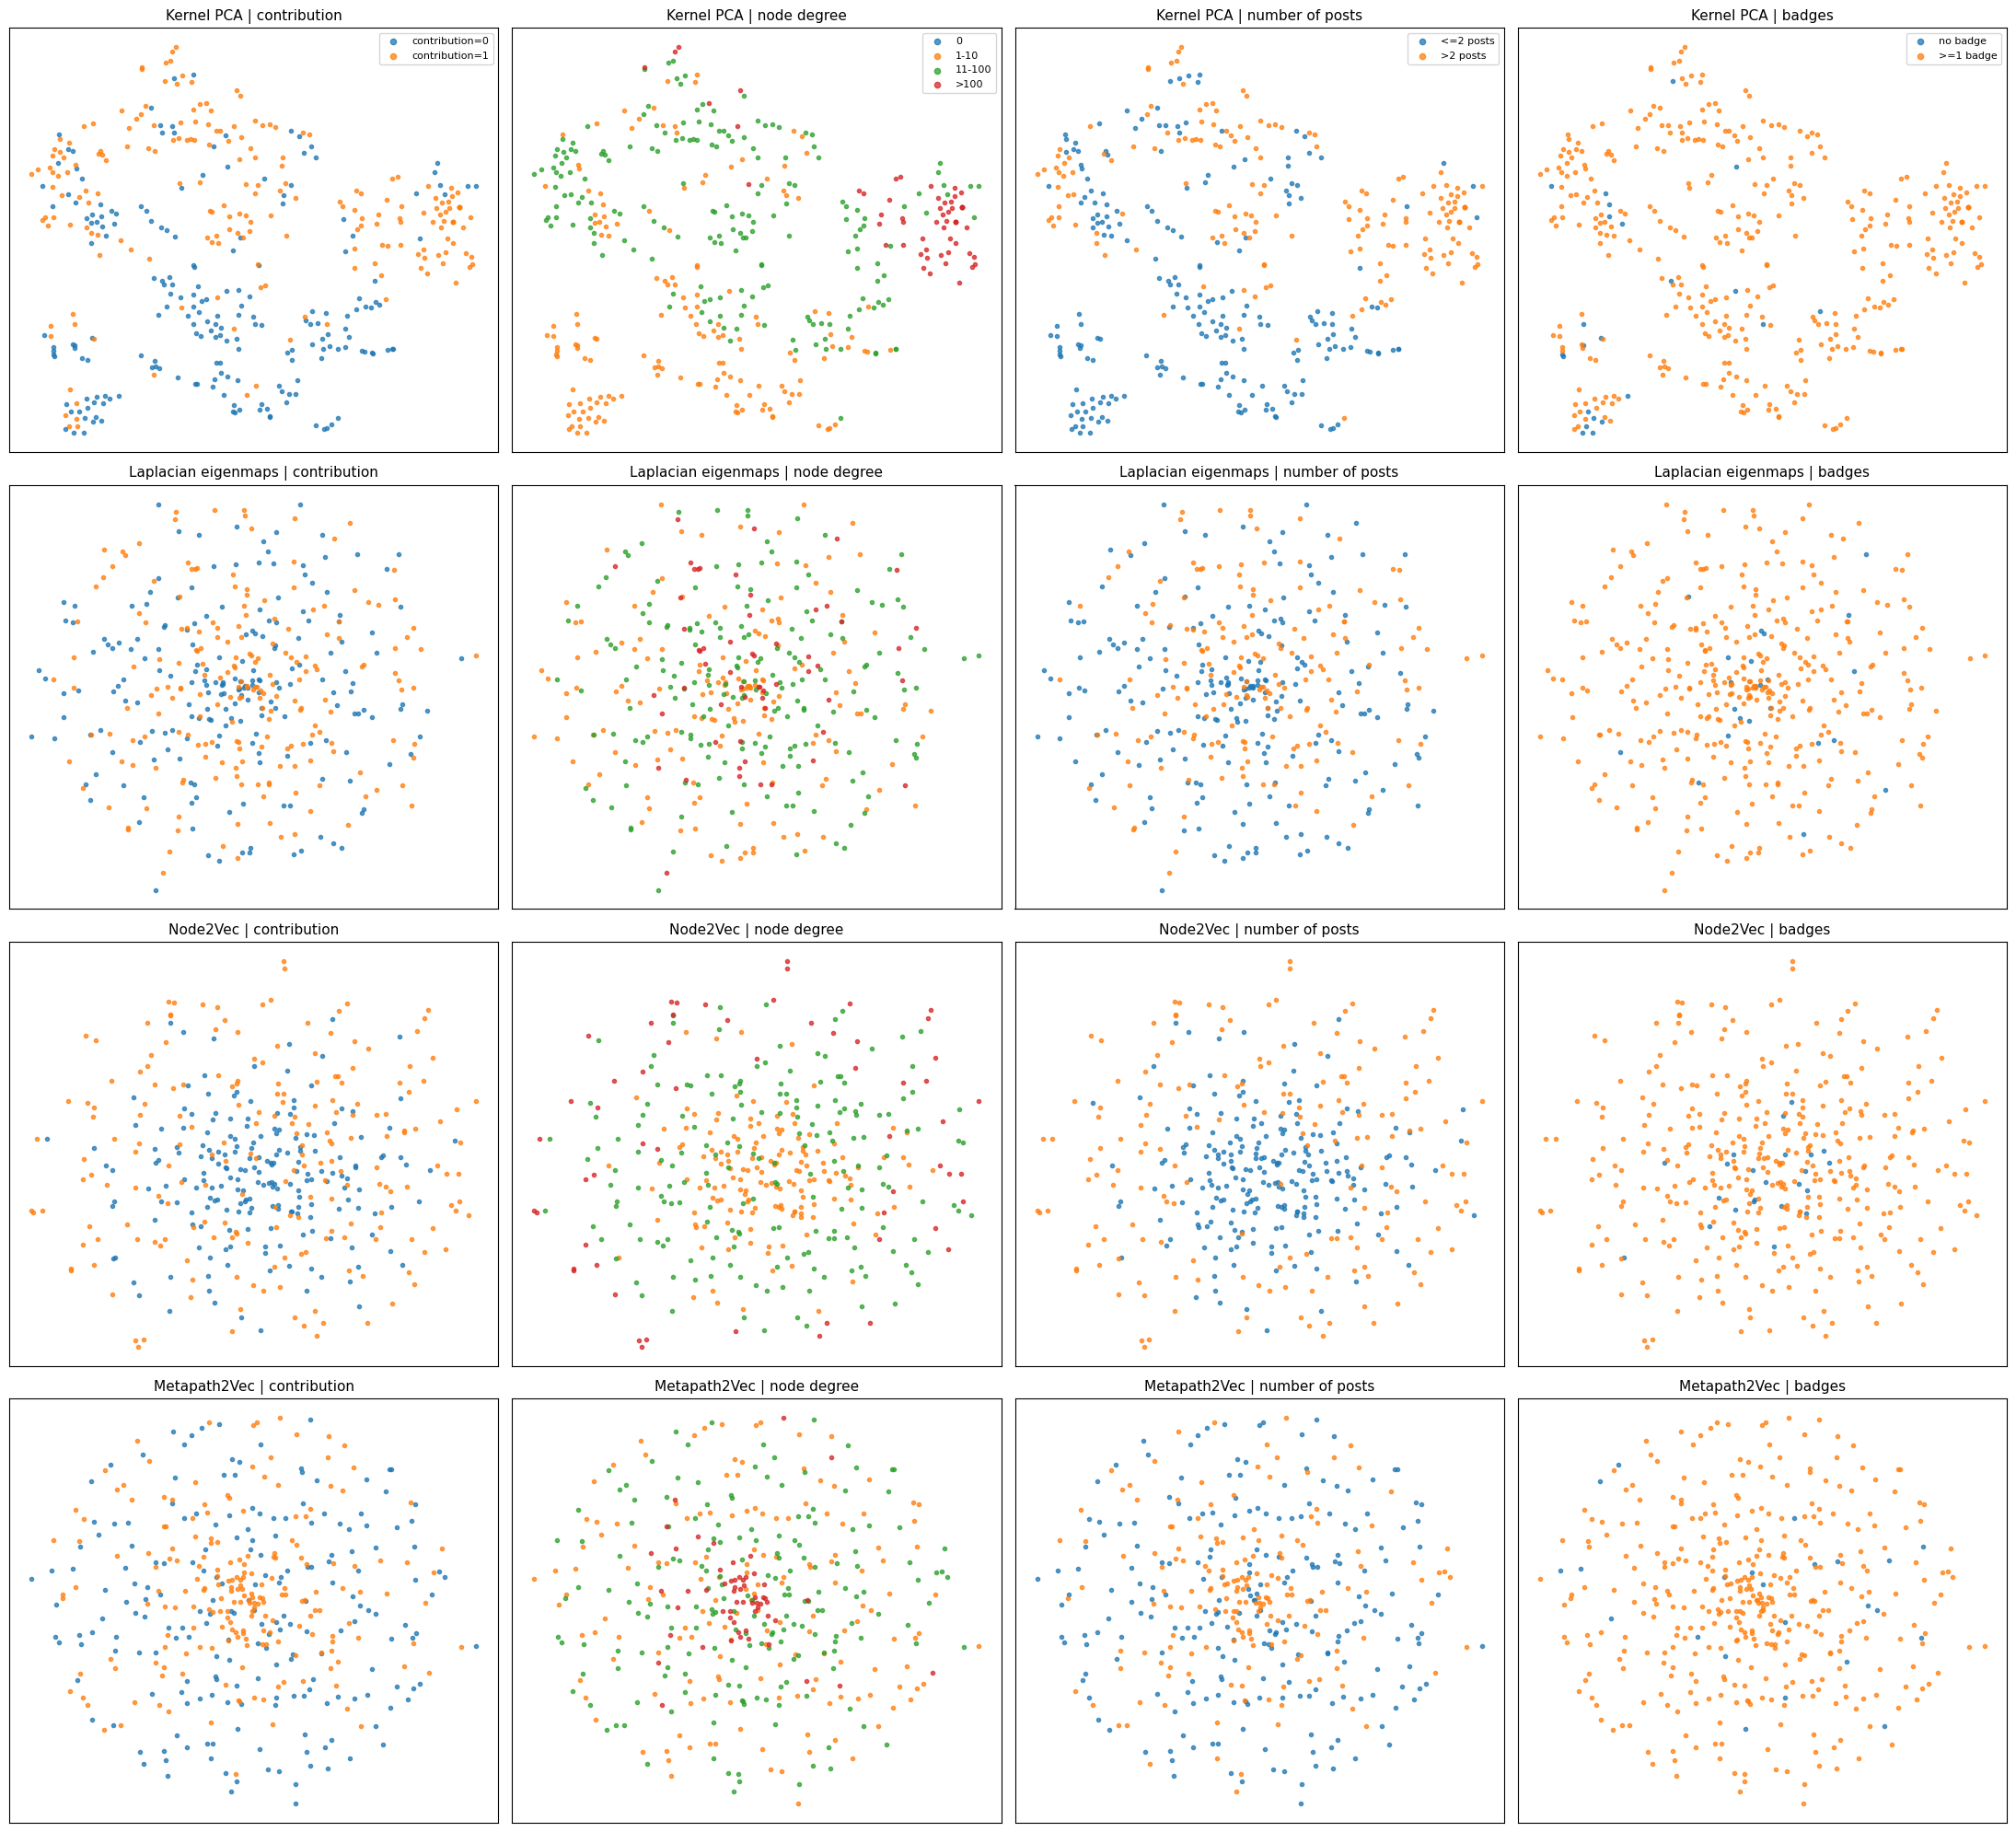

In [10]:
# ---------- Q4: the 4x4 figure ----------
fig, axes = plt.subplots(4, 4, figsize=(22, 20))
palette = plt.cm.tab10.colors
for i, (mname, P) in enumerate(xy2d.items()):
    for j, (cname, (cvals, labels)) in enumerate(colorings.items()):
        ax = axes[i, j]
        for v, lab in enumerate(labels):
            mask = cvals == v
            ax.scatter(P[mask, 0], P[mask, 1], s=9, color=palette[v], label=lab, alpha=0.75)
        ax.set_title(f"{mname} | {cname}", fontsize=11)
        ax.set_xticks([]); ax.set_yticks([])
        if i == 0:
            ax.legend(fontsize=8, markerscale=1.5)
plt.tight_layout()
plt.savefig(f"{ART}/q4_tsne_4x4.png", dpi=150, bbox_inches="tight")
plt.show()

**Q4 answer (patterns we see):**
- The four colorings are strongly correlated with each other: the label, the degree, the number of posts and the badges all measure how active a user is. So inside every row of the figure the same regions tend to light up in all four columns. The badges coloring is the least informative one: almost every sampled user has at least one badge, so the plots are mostly one color.
- Kernel PCA: the clearest structure of the four. The points split into many small, well separated clusters, and the colorings match them almost perfectly: the dense cluster on the right is users with degree above 100 and contribution=1, while the lower clusters are inactive users with few posts and contribution=0. The label separation is the sharpest here, since this embedding compresses the hw1 features that were engineered exactly for this task.
- Laplacian eigenmaps: the weakest structure. The projection is one diffuse cloud, the two labels are mixed almost everywhere, and only a mild degree pattern is visible. The 128 spectral coordinates capture mostly global community structure of the huge graph, which does not align well with the label.
- Node2Vec: a clear radial activity pattern. Users with low degree, few posts and contribution=0 sit in the middle of the cloud, while users with higher degree and contribution=1 sit toward the outside. The separation is visible but soft, with no sharp clusters.
- Metapath2Vec: a dense central cluster of very active users (degree above 100, more than 2 posts, mostly contribution=1), surrounded by a diffuse cloud of less active users where the labels mix. Users with little post and comment activity are barely visited by the user-post-comment walks, so their embeddings stay weakly trained and unstructured.

### Q5 - Downstream performance per embedding

The best model in assignment 1 was XGBoost (max_depth=4, n_estimators=200, learning_rate=0.1, class weighted with scale_pos_weight). We train it on each embedding: the train rows come from the train task table, evaluation is on train and validation. For the node embedding methods, every task row gets the embedding of its user node. Each table cell is train/val.

In [11]:
# ---------- Q5: eval harness + downstream run per base embedding ----------
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, precision_score,
                             recall_score, f1_score)

def eval_split(y_true, y_score):
    y_pred = (y_score >= 0.5).astype(int)
    return {"accuracy":  accuracy_score(y_true, y_pred),
            "roc_auc":   roc_auc_score(y_true, y_score),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall":    recall_score(y_true, y_pred),
            "f1":        f1_score(y_true, y_pred)}

def run_xgb(X_tr, y_tr, X_va, y_va):
    # best hw1 model and hyperparameters
    pos_ratio = float((y_tr == 0).sum() / (y_tr == 1).sum())
    clf = XGBClassifier(max_depth=4, n_estimators=200, learning_rate=0.1,
                        scale_pos_weight=pos_ratio, tree_method="hist",
                        n_jobs=-1, random_state=SEED, eval_metric="logloss")
    clf.fit(X_tr, y_tr)
    return (eval_split(y_tr, clf.predict_proba(X_tr)[:, 1]),
            eval_split(y_va, clf.predict_proba(X_va)[:, 1]))

def emb_xy(name):
    """Train/val embedding matrices for one method, rows aligned with the task tables.
    'A + B' returns the concatenation of methods A and B."""
    if " + " in name:
        a, b = name.split(" + ")
        Xa_tr, Xa_va = emb_xy(a)
        Xb_tr, Xb_va = emb_xy(b)
        return np.hstack([Xa_tr, Xb_tr]), np.hstack([Xa_va, Xb_va])
    if name == "Kernel PCA":
        return kpca_train, kpca_val
    if name == "Laplacian eigenmaps":
        return user_rows(lap_emb, uid_train, OFF_USERS), user_rows(lap_emb, uid_val, OFF_USERS)
    if name == "Node2Vec":
        return user_rows(n2v_emb, uid_train, OFF_USERS), user_rows(n2v_emb, uid_val, OFF_USERS)
    if name == "Metapath2Vec":
        return user_rows(m2v_users, uid_train), user_rows(m2v_users, uid_val)
    raise ValueError(name)

def fmt_row(name, m_tr, m_va):
    row = {"embedding": name}
    for m in ["accuracy", "roc_auc", "precision", "recall", "f1"]:
        row[m] = f"{m_tr[m]:.3f}/{m_va[m]:.3f}"
    return row

BASE = ["Kernel PCA", "Laplacian eigenmaps", "Node2Vec", "Metapath2Vec"]
metrics_all, table_rows = {}, []
for name in BASE:
    t0 = time.time()
    X_tr, X_va = emb_xy(name)
    m_tr, m_va = run_xgb(X_tr, y_train, X_va, y_val)
    metrics_all[name] = (m_tr, m_va)
    table_rows.append(fmt_row(name, m_tr, m_va))
    print(f"{name}: val AUC={m_va['roc_auc']:.3f}, val F1={m_va['f1']:.3f} ({time.time() - t0:.0f}s)")
    del X_tr, X_va; gc.collect()

pd.DataFrame(table_rows)

Kernel PCA: val AUC=0.868, val F1=0.233 (25s)
Laplacian eigenmaps: val AUC=0.663, val F1=0.081 (33s)
Node2Vec: val AUC=0.773, val F1=0.175 (25s)
Metapath2Vec: val AUC=0.706, val F1=0.101 (27s)


,embedding,accuracy,roc_auc,precision,recall,f1
0,Kernel PCA,0.819/0.868,0.915/0.868,0.197/0.139,0.853/0.717,0.320/0.233
1,Laplacian eigenmaps,0.575/0.584,0.749/0.663,0.086/0.043,0.784/0.657,0.156/0.081
2,Node2Vec,0.848/0.853,0.876/0.773,0.207/0.104,0.722/0.553,0.322/0.175
3,Metapath2Vec,0.711/0.706,0.778/0.706,0.112/0.055,0.690/0.586,0.192/0.101


### Q6 - Concatenated embeddings

Same classification process for concatenations of two embeddings (per node, the vectors are concatenated to a 256-dimensional input). Emb + Emb duplicates the best base embedding from Q5 and serves as a baseline: it doubles the number of inputs without adding new information, so it isolates the effect of just having more parameters.

In [12]:
# ---------- Q6: concatenated embeddings, added to the same table ----------
best_base = max(BASE, key=lambda n: metrics_all[n][1]["roc_auc"])
print("best base embedding (by val AUC):", best_base)

COMBOS = ["Kernel PCA + Node2Vec",
          "Kernel PCA + Laplacian eigenmaps",
          "Kernel PCA + Metapath2Vec",
          "Node2Vec + Metapath2Vec",
          f"{best_base} + {best_base}"]

for name in COMBOS:
    t0 = time.time()
    X_tr, X_va = emb_xy(name)
    m_tr, m_va = run_xgb(X_tr, y_train, X_va, y_val)
    metrics_all[name] = (m_tr, m_va)
    table_rows.append(fmt_row(name, m_tr, m_va))
    print(f"{name}: val AUC={m_va['roc_auc']:.3f}, val F1={m_va['f1']:.3f} ({time.time() - t0:.0f}s)")
    del X_tr, X_va; gc.collect()

results_df = pd.DataFrame(table_rows)
results_df.to_csv(f"{ART}/q5_q6_results.csv", index=False)
results_df

best base embedding (by val AUC): Kernel PCA
Kernel PCA + Node2Vec: val AUC=0.862, val F1=0.247 (49s)
Kernel PCA + Laplacian eigenmaps: val AUC=0.866, val F1=0.233 (50s)
Kernel PCA + Metapath2Vec: val AUC=0.868, val F1=0.237 (48s)
Node2Vec + Metapath2Vec: val AUC=0.774, val F1=0.175 (49s)
Kernel PCA + Kernel PCA: val AUC=0.868, val F1=0.233 (49s)


,embedding,accuracy,roc_auc,precision,recall,f1
0,Kernel PCA,0.819/0.868,0.915/0.868,0.197/0.139,0.853/0.717,0.320/0.233
1,Laplacian eigenmaps,0.575/0.584,0.749/0.663,0.086/0.043,0.784/0.657,0.156/0.081
2,Node2Vec,0.848/0.853,0.876/0.773,0.207/0.104,0.722/0.553,0.322/0.175
3,Metapath2Vec,0.711/0.706,0.778/0.706,0.112/0.055,0.690/0.586,0.192/0.101
4,Kernel PCA + Node2Vec,0.832/0.880,0.922/0.862,0.210/0.150,0.855/0.703,0.337/0.247
5,Kernel PCA + Laplacian eigenmaps,0.818/0.868,0.915/0.866,0.197/0.139,0.855/0.713,0.320/0.233
6,Kernel PCA + Metapath2Vec,0.819/0.870,0.916/0.868,0.198/0.142,0.856/0.717,0.321/0.237
7,Node2Vec + Metapath2Vec,0.851/0.855,0.878/0.774,0.211/0.104,0.724/0.548,0.327/0.175
8,Kernel PCA + Kernel PCA,0.819/0.868,0.915/0.868,0.197/0.139,0.853/0.717,0.320/0.233


**Q7 answer:**

How well each embedding captured the difference between the two populations, based on the t-SNE plots (Q4) and the table (Q5/Q6):

- Kernel PCA: captured the difference best among the base methods (val AUC 0.868, F1 0.233). It compresses the hw1 features, which already contain the task signal, and this also shows in the t-SNE plot, where the positives concentrate in clear clusters.
- Node2Vec: second best (val AUC 0.773). Its radial t-SNE pattern matches this: it encodes how active and connected a user is, which correlates with the label, but with much less detail than the engineered features. Its accuracy looks high (0.853) but the recall is low (0.553), so it misses many positives.
- Metapath2Vec: weaker (val AUC 0.706). It represents the very active users well (the dense center in its t-SNE plot), but the many low-activity users are barely trained, because the user-post-comment metapath never visits votes and badges.
- Laplacian eigenmaps: weakest (val AUC 0.663, F1 0.081). Its global spectral structure does not align with the label, as its fully mixed t-SNE plot shows.
- Concatenations: no combination improved the val AUC over Kernel PCA alone (Kernel PCA + Node2Vec 0.862, + Laplacian 0.866, + Metapath2Vec 0.868, against 0.868 alone). Kernel PCA + Node2Vec did give the best accuracy (0.880), precision (0.150) and F1 (0.247), so the graph structure helps a little at the 0.5 decision threshold, but it adds almost no ranking information beyond the hw1 features, which already include graph features such as the degree. Node2Vec + Metapath2Vec (0.774) is the same as Node2Vec alone, so the two walk methods are largely redundant with each other. The Emb + Emb baseline (Kernel PCA + Kernel PCA, 0.868) is identical to Kernel PCA alone, which confirms that just doubling the input width changes nothing, so any real gain of a combination must come from new information.

Best predictive performance: Kernel PCA (alone or with Metapath2Vec) by val AUC at 0.868, and Kernel PCA + Node2Vec by val F1 at 0.247.

**Q8 answer:**

In assignment 1 the best model (XGBoost) reached val ROC AUC 0.879 (F1 0.153) on the tabular features alone, and val ROC AUC 0.865 (F1 0.294) after adding the graph features. The best embedding result here is val AUC 0.868 (Kernel PCA), so no embedding method improved over the generated features: 0.868 is below the 0.879 of the raw hw1 features, and the best embedding F1 (0.247, Kernel PCA + Node2Vec) is below the 0.294 of hw1. The pure graph embeddings stayed far behind (0.663 to 0.773).

This is expected. The embeddings are task-agnostic and compress everything into 128 numbers, while the hw1 features were engineered with this exact task in mind, and the tree model can use those raw features directly without a lossy compression in between. Kernel PCA comes closest exactly because it is a compression of those same engineered features. It is still interesting that it loses only about 0.01 AUC after compressing 50 features through a 128-dimensional kernel space, and that the graph-walk embeddings recover a large part of the signal (0.77 AUC) without any feature engineering at all.

### Q9 - Qualitative analysis: 2-hop neighborhoods

We pick 3 user nodes from the validation table with degree between 3 and 8 (so the picture stays readable), draw their 2-hop neighborhood (sampling at most 7 neighbors per node), and list for every visualized node v: its table, its id, and the cosine similarity between v and u in each of the 4 base embeddings. Kernel PCA embeds tuples of the task table, so its similarity is defined only between users that appear in the validation table. Metapath2Vec covers only users, posts and comments. Undefined cells show NaN.

chosen users: [92149, 143079, 204573]


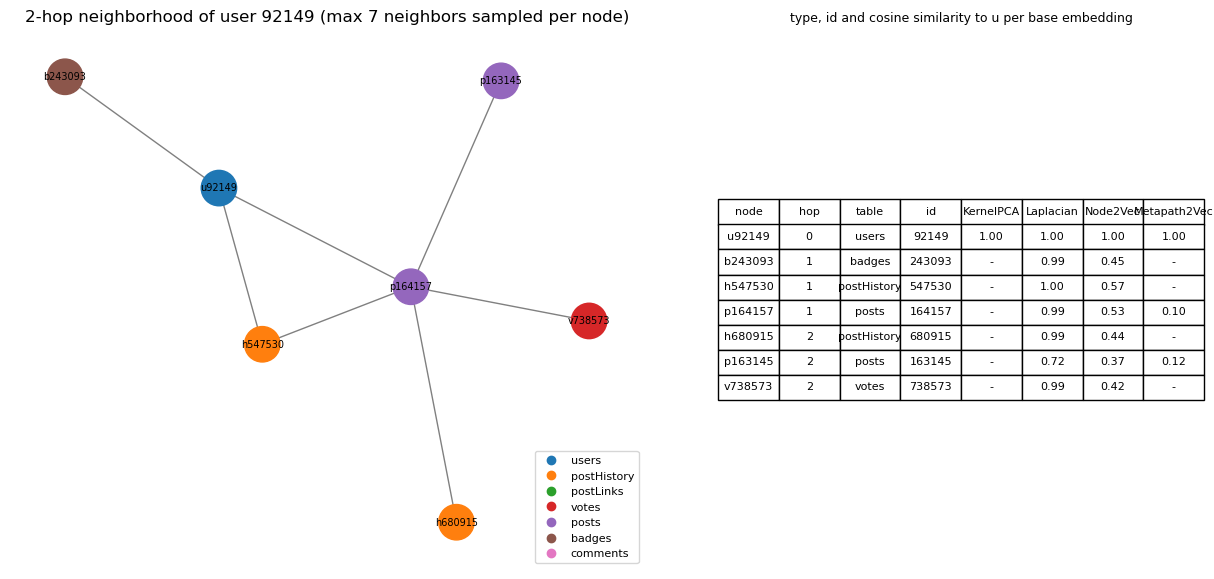

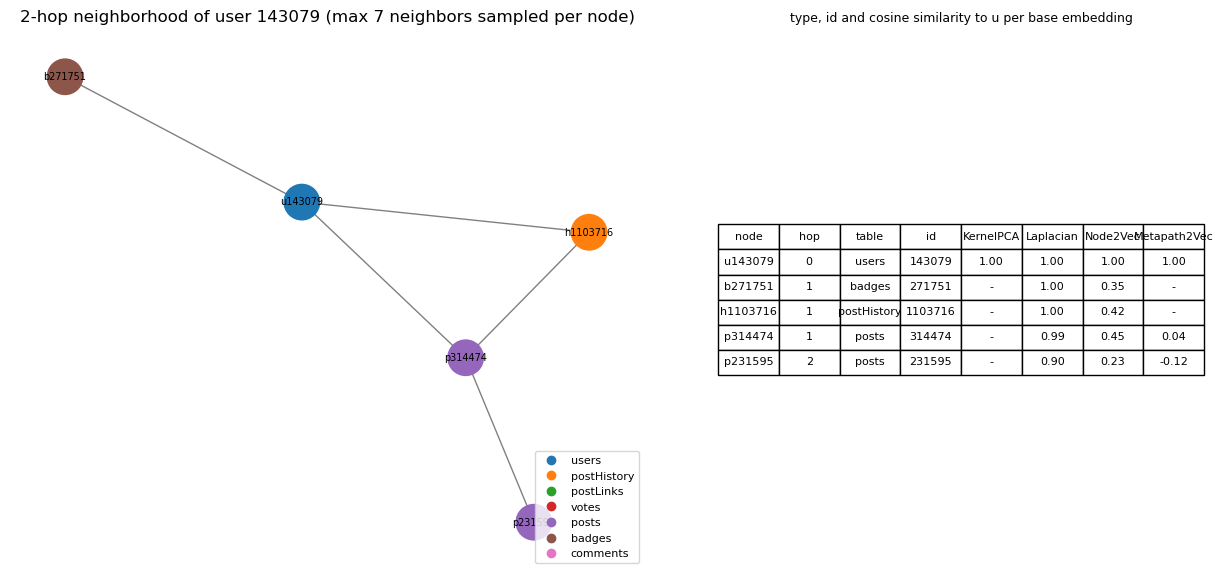

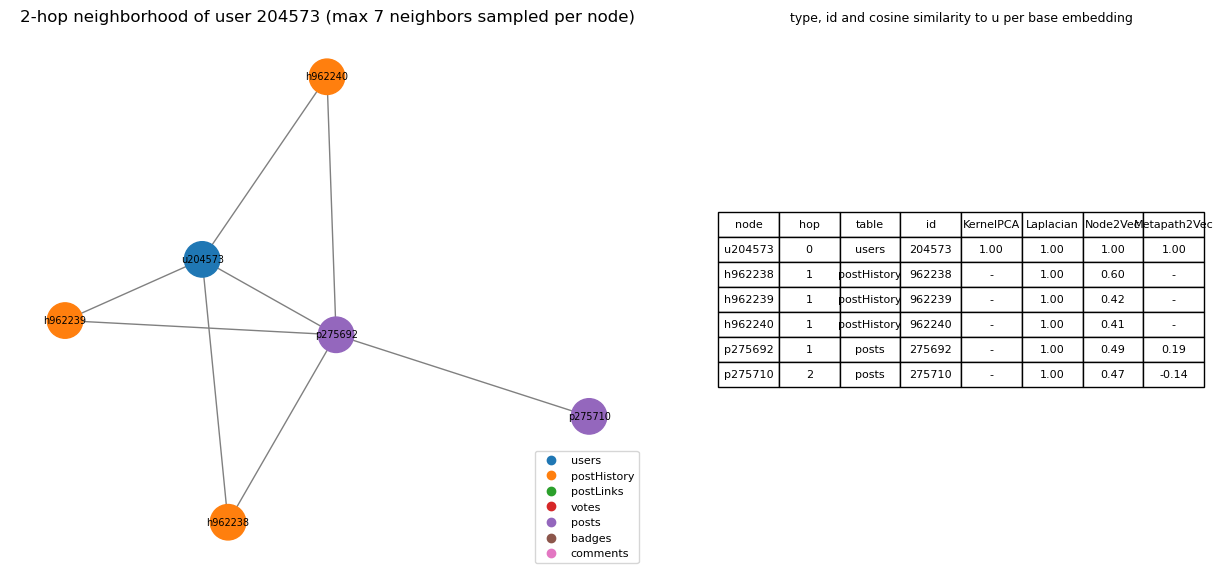

In [13]:
# ---------- Q9: 2-hop neighborhood visualizations ----------
import networkx as nx

n_all = G["num_nodes"]
r, c = G["edge_index"].numpy()
A_csr = sp.csr_matrix((np.ones(len(r), np.float32), (r, c)), shape=(n_all, n_all))
A_csr.sum_duplicates()

ntypes = G["node_types"]
node_type_arr = G["node_type"].numpy()
ABBREV = {"users": "u", "posts": "p", "comments": "c", "votes": "v",
          "badges": "b", "postHistory": "h", "postLinks": "l"}
TYPE_COLOR = {t: plt.cm.tab10.colors[i] for i, t in enumerate(ntypes)}

def info(i):
    """homogeneous node id -> (table name, local id)"""
    t = ntypes[node_type_arr[i]]
    return t, int(i - G["offsets"][t])

val_row_of_user = {}
for i, u in enumerate(uid_val):
    val_row_of_user.setdefault(int(u), i)

def cos(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    return float(a @ b / (na * nb)) if na > 0 and nb > 0 else float("nan")

def sim_entry(u, v):
    """cosine similarity of nodes u and v in each base embedding"""
    tu, lu = info(u); tv, lv = info(v)
    out = {}
    if tu == "users" and tv == "users" and lu in val_row_of_user and lv in val_row_of_user:
        out["KernelPCA"] = cos(kpca_val[val_row_of_user[lu]], kpca_val[val_row_of_user[lv]])
    else:
        out["KernelPCA"] = float("nan")
    out["Laplacian"] = cos(lap_emb[u], lap_emb[v])
    out["Node2Vec"] = cos(n2v_emb[u], n2v_emb[v])
    if tu in m2v_embs and tv in m2v_embs:
        out["Metapath2Vec"] = cos(m2v_embs[tu][lu], m2v_embs[tv][lv])
    else:
        out["Metapath2Vec"] = float("nan")
    return out

def neighbors(i, cap, rng):
    nb = A_csr.indices[A_csr.indptr[i]:A_csr.indptr[i + 1]]
    return rng.choice(nb, cap, replace=False) if len(nb) > cap else nb

def show_two_hop(uid, cap=7):
    u = OFF_USERS + int(uid)
    rng = np.random.RandomState(SEED)
    edges, hops = [], {u: 0}
    for v in neighbors(u, cap, rng):
        v = int(v)
        edges.append((u, v)); hops.setdefault(v, 1)
    for v in [x for x, h in list(hops.items()) if h == 1]:
        for w in neighbors(v, cap, rng):
            w = int(w)
            if w != u:
                edges.append((v, w)); hops.setdefault(w, 2)
    Gx = nx.Graph(); Gx.add_node(u); Gx.add_edges_from(edges)

    labels = {i: f"{ABBREV[info(i)[0]]}{info(i)[1]}" for i in Gx.nodes}
    colors = [TYPE_COLOR[info(i)[0]] for i in Gx.nodes]

    # graph on the left, the per-node similarity table on the right
    fig, (ax_g, ax_t) = plt.subplots(
        1, 2, figsize=(15, 7), gridspec_kw={"width_ratios": [1.5, 1]})
    pos = nx.spring_layout(Gx, seed=SEED)
    nx.draw(Gx, pos, ax=ax_g, node_color=colors, labels=labels, node_size=650,
            font_size=7, edge_color="gray")
    handles = [plt.Line2D([], [], marker="o", ls="", color=TYPE_COLOR[t], label=t)
               for t in ntypes]
    ax_g.legend(handles=handles, fontsize=8, loc="lower right")
    ax_g.set_title(f"2-hop neighborhood of user {uid} "
                   f"(max {cap} neighbors sampled per node)")

    rows_ = []
    for i in Gx.nodes:
        t, lid = info(i)
        rows_.append({"node": labels[i], "hop": hops[i], "table": t, "id": lid,
                      **sim_entry(u, i)})
    df = pd.DataFrame(rows_).sort_values(["hop", "table", "id"]).reset_index(drop=True)

    def fmt(x):
        return "-" if (isinstance(x, float) and np.isnan(x)) else (
            f"{x:.2f}" if isinstance(x, float) else str(x))
    cell_text = [[fmt(v) for v in row] for row in df.values]
    ax_t.axis("off")
    tbl = ax_t.table(cellText=cell_text, colLabels=list(df.columns),
                     loc="center", cellLoc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8)
    tbl.scale(1.15, 1.5)
    ax_t.set_title("type, id and cosine similarity to u per base embedding",
                   fontsize=9)
    plt.savefig(f"{ART}/q9_user_{uid}.png", dpi=150, bbox_inches="tight")
    plt.show()

deg_val_users = np.full(len(uid_val), -1, dtype=np.int64)
m = uid_val < N_USERS
deg_val_users[m] = deg_arr[OFF_USERS + uid_val[m]]
ok = np.where((deg_val_users >= 3) & (deg_val_users <= 8))[0]
chosen_users = [int(uid_val[ok[0]]), int(uid_val[ok[len(ok) // 2]]), int(uid_val[ok[-1]])]
print("chosen users:", chosen_users)
for uid in chosen_users:
    show_two_hop(uid)

**Q9 answer (differences between the embedding methods):**
- Laplacian eigenmaps gives almost the same, very high similarity (0.99 and up) to everything in the neighborhood, including 2-hop nodes, and only drops for some 2-hop posts (0.72, 0.90). It is a very smooth embedding: it sees the whole local region as one community and cannot tell the hops apart.
- Node2Vec is the most informative locally: direct neighbors get moderate similarity (about 0.35 to 0.6) and 2-hop nodes get less (about 0.23 to 0.47). The similarity decays with the hop distance, so it actually discriminates between closer and farther nodes.
- Metapath2Vec only covers users, posts and comments, so most rows are NaN (badges, votes and postHistory have no embedding). Even the user's own posts get low similarity (0.04 to 0.2, sometimes negative at hop 2). These low-degree users are rarely visited by user-post-comment walks, so their vectors are barely trained, which matches the diffuse outer cloud we saw in the Q4 t-SNE plot.
- Kernel PCA is only defined between user nodes that appear in the validation table. The 2-hop neighborhoods of our three low-degree users contain no other user at all, only their posts, badges, votes and edit-history records, so its column is NaN for every node except u itself. This shows the coverage difference clearly: the tuple embedding compares task rows (users), while the node embeddings can compare any two tuples in the database.

## Part 3: Questions

### Q10 - Encoder-decoder view of each base method

All four methods fit the encoder-decoder paradigm: an encoder ENC(u) = z_u maps a tuple or node to a k-dimensional vector, a decoder DEC(z_u, z_v) tries to reconstruct a chosen proximity S(u, v), and the loss measures how well the decoded values match the proximity.

**Kernel PCA**
- Encoder: a linear projection in kernel feature space, z = V^T phi(x), where phi is the (approximate) RBF feature map of the tuple's feature vector. It is not a lookup table: a new tuple can be encoded directly from its features.
- Decoder: inner product, DEC(z_u, z_v) = z_u . z_v.
- Proximity: the RBF kernel similarity K(x_u, x_v) between the tuples' feature vectors.
- Loss: the squared (Frobenius) reconstruction error of the kernel matrix, sum over pairs of (z_u . z_v - K(x_u, x_v))^2.
- Aims to preserve: the global pairwise feature similarity, keeping the directions of largest variance in kernel space.

**Laplacian eigenmaps**
- Encoder: embedding lookup (one free vector per node).
- Decoder: squared Euclidean distance, DEC(z_u, z_v) = ||z_u - z_v||^2.
- Proximity: the (normalized) adjacency, S(u, v) = 1 if a PK-FK edge connects u and v.
- Loss: sum over pairs of S(u, v) * ||z_u - z_v||^2, under a normalization constraint that prevents the trivial all-equal solution. The solution is given by the bottom eigenvectors of the graph Laplacian.
- Aims to preserve: first-order, local connectivity. Direct neighbors are placed close together.

**Node2Vec**
- Encoder: embedding lookup.
- Decoder: softmax over inner products, p(v | u) proportional to exp(z_u . z_v).
- Proximity: the probability that v appears in a window (context size 5) around u on fixed-length random walks (length 24).
- Loss: cross entropy between the decoded distribution and the empirical walk co-occurrences, optimized with negative sampling (skip-gram).
- Aims to preserve: multi-hop stochastic neighborhood overlap. Nodes whose random walk neighborhoods overlap a lot get similar embeddings.

**Metapath2Vec**
- Encoder, decoder and loss: the same as Node2Vec (skip-gram with negative sampling).
- Proximity: co-occurrence on random walks that are forced to follow the metapath user-post-comment-user.
- Aims to preserve: schema-aware (semantic) proximity in the heterogeneous graph. Only relations along the chosen metapath matter, so users connected through posts and comments become similar, while other relations (votes, badges, post history) are ignored.

### Q11 - Why are embedding methods task-agnostic

**Q11 answer:** Because they are trained without the task labels. The objective only preserves some notion of proximity of the data itself (kernel similarity of features, adjacency, walk co-occurrence), and never mentions the label we want to predict. The same embedding can therefore be computed once and reused as input for many different downstream tasks. The price is that nothing forces the embedding to keep exactly the information that our specific task needs.

### Q12 - The two tricks for handling the large matrices

**Q12 answer:**
- Nystroem (Q1): pick m landmark rows (m=256 here). Compute the kernel only between all n points and the m landmarks (an n x m matrix) and between the landmarks themselves (m x m). The eigendecomposition of the small m x m landmark kernel gives an explicit m-dimensional feature map whose inner products approximate the full kernel. The n x n kernel matrix is never built.
- randomized_svd (Q3a): multiply the matrix by a small random matrix to sketch its range (with a few power iterations for accuracy), orthonormalize the sketch, project the matrix onto it, and run an exact SVD on the small projected matrix. It only needs matrix products, so it is cheap for a sparse 4.1M x 4.1M adjacency with ~11M nonzeros.
- Could we use randomized_svd for the kernel PCA of Q1? No. Kernel PCA needs the spectrum of the n x n kernel matrix, not of the data matrix. randomized_svd has to multiply by the matrix it factorizes, so we would first need to materialize (or repeatedly recompute) a dense 1.36M x 1.36M RBF kernel matrix. That matrix is exactly the thing that does not fit in memory, and it is dense, so the sparse trick does not help either. Running randomized_svd directly on the feature matrix would only give plain truncated SVD (linear PCA), not kernel PCA with an RBF proximity.

### Q13 - Walk length vs metapath length in metapath2vec

**Q13 answer:** The walk is generated by following the metapath relations step by step, repeating the metapath cyclically. The constraints are:
- The walk should be at least as long as the metapath, otherwise the pattern is never completed even once. In practice it should be several times longer (here: walk length 24 = 8 repetitions of the 3-edge metapath), so that one walk produces many context windows for training.
- If the walk is longer than the metapath, the metapath must be cyclic: it has to end at the same node type it starts from (ours starts and ends at user). Otherwise, after one pass there is no valid relation for the next step.
- The walk must also be long enough for the context window: walk_length + 1 >= context_size, otherwise no (center, context) pairs can be cut out of the walk.

### Q14 - Summary

**a. Steps we took and what we learned.**
- We turned the hw1 feature matrix into a numeric matrix and compressed it with approximate kernel PCA (Nystroem + PCA). We learned how kernel methods are scaled to millions of rows: only through approximations, never through the full kernel matrix.
- We built the PK-FK graph with relbench's built-in tools (4.1M nodes, 5.6M edges) and computed its statistics. We learned that the heterograph utilities replace a lot of the manual networkx work from hw1.
- We trained three node embeddings: Laplacian eigenmaps (randomized SVD over a sparse normalized adjacency), Node2Vec and Metapath2Vec (skip-gram over random walks, sparse Adam). We learned the practical side of each: sparse representations for spectral methods, batching and sparse gradients for walk methods, and how the metapath controls what a walker can see.
- We compared the embeddings visually (t-SNE), through a downstream classifier (XGBoost), and qualitatively (2-hop neighborhoods). We learned that in this dataset most of the visible structure in every embedding is some version of "how active is the user".

**b. Feature extraction vs learning embeddings.**
In the previous assignment the analyst makes explicit, local decisions: which tables to join, which aggregations to compute, which time windows to use, and every resulting feature has a clear meaning. In embedding learning the analyst instead chooses the method, the proximity it should preserve (kernel similarity, adjacency, walk co-occurrence, metapath), the dimension k, and the training hyperparameters (walk length, context, epochs, learning rate); the features themselves come out of an optimization and have no individual meaning. Advantages of embeddings: no manual feature design, they capture structure that is hard to express as a join-aggregate (multi-hop relationships), they are reusable across tasks, and they give a fixed-size compact representation. Disadvantages: they are not interpretable, they are task-agnostic so they may spend capacity on structure that is useless for the task, they require training time and tuning, and they handle new or isolated nodes badly.

**c. Graph embeddings vs tabular embeddings, based on our results.**
The tabular embedding (kernel PCA) gave the best downstream results (val AUC 0.868, close to the raw hw1 features), because it compresses features that were engineered for this exact task, and it covers every tuple, including completely inactive users. Its weakness is that it fully depends on the quality of the hw1 feature engineering and sees nothing that was not turned into a feature. The graph embeddings required no feature engineering at all and still recovered a useful activity and connectivity signal (Node2Vec reached 0.773 val AUC from pure structure), but that signal turned out to be almost completely contained in the engineered features: concatenating them with kernel PCA did not raise the val AUC and only gave a small F1 gain (0.247 against 0.233). Their other weaknesses: weakly connected users carry almost no signal, attribute values are ignored completely, and each method preserves only the one proximity it was trained on (most visible in Metapath2Vec, which sees only user-post-comment relations and reached just 0.706).

### Q15 - Packages used

**Q15 answer:** relbench (dataset, task tables, heterograph construction), pytorch (tensors and training), torch-geometric / PyG (Node2Vec and MetaPath2Vec implementations), pyg-lib (fast random walk backend for PyG), scikit-learn (SimpleImputer, StandardScaler, Nystroem, PCA, randomized_svd, TSNE, metrics), scipy (sparse matrices), xgboost (downstream classifier), pandas and numpy (data handling), matplotlib (plots), networkx (the Q9 neighborhood drawings).

### Q16 - AI usage

**Q16 answer:** We used Claude (Claude Code by Anthropic, inside VSCode) for most of the coding work in this assignment: drafting the notebook cells (relbench graph construction, the embedding training loops, the evaluation harness, the plots) and first drafts of the textual answers, which we then edited. Our validation process: we read every generated cell before running it, checked shapes and dtypes of intermediate results, compared the graph statistics against the rel-stack table sizes, verified that the training losses decrease over the epochs, and sanity-checked the downstream metrics against our assignment 1 results (same task, so the numbers must be in a similar range). API details the model was not sure about (for example how PyG MetaPath2Vec handles dead-end walks, and how relbench reindexes primary keys after filtering by time) were verified by reading the package source code. We estimate that around 70 percent of the total workflow was assisted by AI; the design decisions, the actual runs and the final interpretation of the results were ours.

---
Export for submission: `jupyter nbconvert --to html hw2.ipynb`